=== DATASET ASLI YANG DIBACA ===
   Makanan  Kalori (kcal)  Lemak (g)  Gula (g)  Protein (g)  Serat (g)  \
0     Apel             52        0.2      10.4          0.3        2.4   
1   Pisang             89        0.3      12.2          1.1        2.6   
2  Alpukat            160       15.0       0.7          2.0        6.7   
3    Bayam             23        0.4       0.4          2.9        2.2   
4  Brokoli             34        0.4       1.7          2.8        2.6   

   Natrium (mg)  Karbohidrat (g)  
0             1             13.8  
1             1             22.8  
2             7              8.5  
3            79              3.6  
4            33              6.7   

-> [OTOMATIS] Kolom Angka (Dimensi PCA) yang terdeteksi (7): ['Kalori (kcal)', 'Lemak (g)', 'Gula (g)', 'Protein (g)', 'Serat (g)', 'Natrium (mg)', 'Karbohidrat (g)']
-> [OTOMATIS] Kolom Teks (Label Grafik) yang terdeteksi: Makanan

=== PERSENTASE VARIANS YANG DIJELASKAN ===
PC 1: 44.10%
PC 2: 25.32%
Total Va

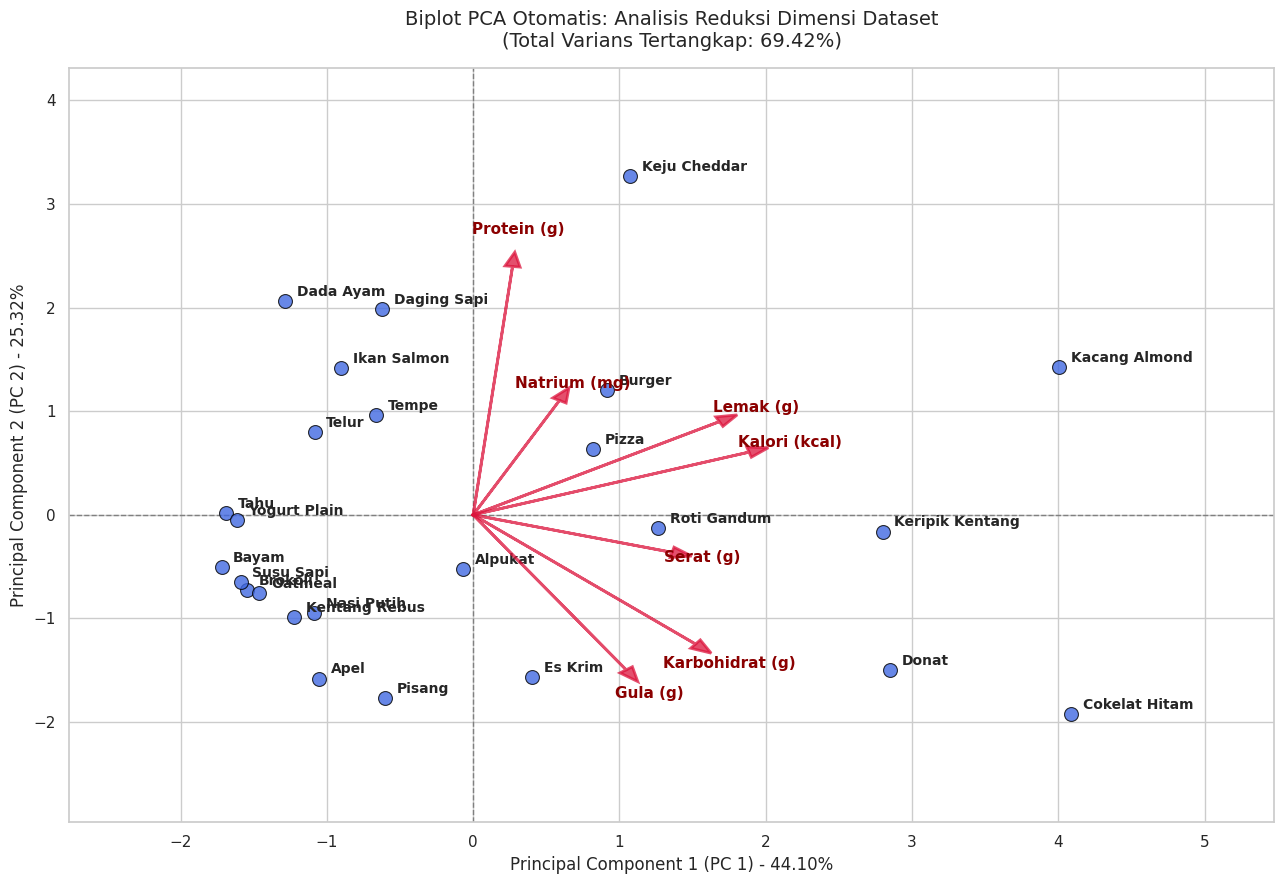

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. MEMBACA DATASET (GANTI NAMA FILE DI SINI)
# ==========================================
# Cukup ganti nama file CSV di bawah ini dengan file data Anda yang lain
file_name = 'data_nutrisi_pca.csv'  # Misal diganti 'data_pelamar_kerja.csv'
df = pd.read_csv(file_name)

print("=== DATASET ASLI YANG DIBACA ===")
print(df.head(), "\n")

# ==========================================
# 2. OTOMATISASI DETEKSI FITUR DAN LABEL
# ==========================================
# Otomatis mengambil kolom numerik (angka) untuk dimasukkan ke PCA
features = df.select_dtypes(include=[np.number]).columns.tolist()

# Otomatis mengambil kolom non-numerik (teks/kategori) untuk dijadikan label teks di grafik
text_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()
# Jika ada kolom teks, gunakan kolom teks pertama sebagai label nama di grafik
label_column = text_columns[0] if text_columns else None

print(f"-> [OTOMATIS] Kolom Angka (Dimensi PCA) yang terdeteksi ({len(features)}): {features}")
print(f"-> [OTOMATIS] Kolom Teks (Label Grafik) yang terdeteksi: {label_column}\n")

# Mengambil matriks nilai numerik
x = df[features].values

# ==========================================
# 3. STANDARISASI FITUR (Scaling Otomatis)
# ==========================================
x_scaled = StandardScaler().fit_transform(x)

# ==========================================
# 4. MENJALANKAN ALGORITMA PCA (2 Dimensi)
# ==========================================
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x_scaled)

# ==========================================
# 5. MEMBUAT DATAFRAME BARU HASIL PCA
# ==========================================
df_pca = pd.DataFrame(data=principalComponents, columns=['PC 1', 'PC 2'])

# Pasangkan kembali label nama jika kolom teks terdeteksi
if label_column:
    df_pca[label_column] = df[label_column].values

# ==========================================
# 6. MENAMPILKAN HASIL EKSPLORASI VARIANS
# ==========================================
print("=== PERSENTASE VARIANS YANG DIJELASKAN ===")
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC {i+1}: {variance*100:.2f}%")
total_variance = sum(pca.explained_variance_ratio_) * 100
print(f"Total Varians yang Ditangkap oleh PC 1 & PC 2: {total_variance:.2f}%\n")

# ==========================================
# 7. VISUALISASI GRAFIK BIPLOT OTOMATIS
# ==========================================
plt.figure(figsize=(13, 9))
sns.set_theme(style="whitegrid")

# Plot titik data hasil reduksi
scatter = sns.scatterplot(
    x='PC 1',
    y='PC 2',
    data=df_pca,
    s=100,
    color='royalblue',
    edgecolor='black',
    alpha=0.8,
    zorder=3
)

# Menambahkan label teks objek secara dinamis di samping setiap titik data
if label_column:
    for i in range(df_pca.shape[0]):
        plt.text(
            x=df_pca['PC 1'][i] + 0.08,
            y=df_pca['PC 2'][i] + 0.05,
            s=df_pca[label_column][i],
            fontdict=dict(size=10, weight='semibold')
        )

# --- MEMBUAT ALIRAN PANAH VEKTOR FITUR SECARA DINAMIS ---
loadings = pca.components_

# Faktor skala dinamis agar panjang panah menyesuaikan bentangan data baru
skala_panah = max(df_pca['PC 1'].max(), abs(df_pca['PC 1'].min())) * 0.85

for i, feature in enumerate(features):
    x_panah = loadings[0, i] * skala_panah
    y_panah = loadings[1, i] * skala_panah

    # Menggambar panah vektor komponen
    plt.arrow(
        0, 0, x_panah, y_panah,
        color='crimson', alpha=0.75, linewidth=2,
        head_width=skala_panah*0.03, head_length=skala_panah*0.04,
        zorder=4
    )

    # Menuliskan nama variabel di ujung panah
    plt.text(
        x_panah * 1.15, y_panah * 1.15,
        feature,
        color='darkred', ha='center', va='center',
        fontdict=dict(size=11, weight='bold'),
        zorder=5
    )

# Menambahkan garis bantu pusat kuadran (0,0)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Pengaturan judul dan label sumbu secara kustom
plt.title(f'Biplot PCA Otomatis: Analisis Reduksi Dimensi Dataset\n(Total Varians Tertangkap: {total_variance:.2f}%)', fontsize=14, pad=15)
plt.xlabel(f'Principal Component 1 (PC 1) - {pca.explained_variance_ratio_[0]*100:.2f}%', fontsize=12)
plt.ylabel(f'Principal Component 2 (PC 2) - {pca.explained_variance_ratio_[1]*100:.2f}%', fontsize=12)

# Mengatur batas tampilan grafik agar fleksibel mengikuti sebaran data baru
plt.xlim(df_pca['PC 1'].min() - skala_panah*0.3, df_pca['PC 1'].max() + skala_panah*0.4)
plt.ylim(df_pca['PC 2'].min() - skala_panah*0.3, df_pca['PC 2'].max() + skala_panah*0.3)

plt.tight_layout()
plt.show()